In [2]:
!pip install segmentation-models-pytorch rasterio

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import rasterio
import cv2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


In [3]:
base_path = "/kaggle/input/datasets/armia123/satellite-img/data"

img_path = os.path.join(base_path, "images", "0.tif")

with rasterio.open(img_path) as src:
    image = src.read()   # (C, H, W)

image_hw = np.transpose(image, (1, 2, 0))
print("Image shape (H,W,C):", image_hw.shape)

mask_path = os.path.join(base_path, "labels", "0.png")

mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

print("Mask shape:", mask.shape)

Image shape (H,W,C): (128, 128, 12)
Mask shape: (128, 128)


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [4]:
BASE_PATH = '/kaggle/input/datasets/armia123/satellite-img/data'

IMAGES_DIR = os.path.join(BASE_PATH, 'images')
LABELS_DIR = os.path.join(BASE_PATH, 'labels')

print('Images: ', len(os.listdir(IMAGES_DIR)))
print('Labels: ', len(os.listdir(LABELS_DIR)))

Images:  306
Labels:  456


In [5]:
import os

image_dir = "/kaggle/input/datasets/armia123/satellite-img/data/images"
label_dir = "/kaggle/input/datasets/armia123/satellite-img/data/labels"

image_names = set(
    os.path.splitext(f)[0]
    for f in os.listdir(image_dir)
    if f.endswith(".tif")
)

label_names = set(
    os.path.splitext(f)[0]
    for f in os.listdir(label_dir)
    if f.endswith(".png")
)

labels_without_images = label_names - image_names

print("CC:", len(labels_without_images))
print("اNames:")
for name in sorted(labels_without_images)[:20]: 
    print(name)

CC: 150
اNames:
100_184
101_89
102_179
103_225
104_20
105_148
106_267
107_59
108_236
109_223
10_244
110_287
111_121
112_78
113_44
114_220
115_49
116_250
117_97
118_125


In [2]:
import os
import shutil

image_dir = r"C:\Users\Armia Gamal\Downloads\New folder (23)\data-20260303T213654Z-1-001\data\images"
label_dir = r"C:\Users\Armia Gamal\Downloads\New folder (23)\data-20260303T213654Z-1-001\data\labels"

output_root = "/kaggle/working/clean_dataset"
output_images = os.path.join(output_root, "images")
output_labels = os.path.join(output_root, "labels")

os.makedirs(output_images, exist_ok=True)
os.makedirs(output_labels, exist_ok=True)

images = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])
labels = sorted([f for f in os.listdir(label_dir) if f.endswith(".png")])

label_set = set(labels)

copied_count = 0

for img_name in images:
    base_name = os.path.splitext(img_name)[0]
    expected_label = base_name + ".png"

    if expected_label in label_set:
        shutil.copy(os.path.join(image_dir, img_name), output_images)
        shutil.copy(os.path.join(label_dir, expected_label), output_labels)
        copied_count += 1

print("Total matched image-mask pairs copied:", copied_count)

Total matched image-mask pairs copied: 306


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02158828064764842..1.0].


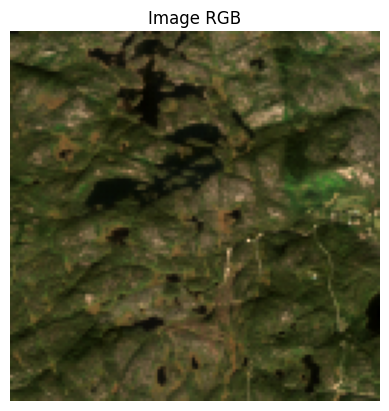

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

rgb = np.stack([image[3], image[2], image[1]], axis=-1)
rgb = rgb / rgb.max()

plt.imshow(rgb)
plt.title('Image RGB')
plt.axis('off')
plt.show()

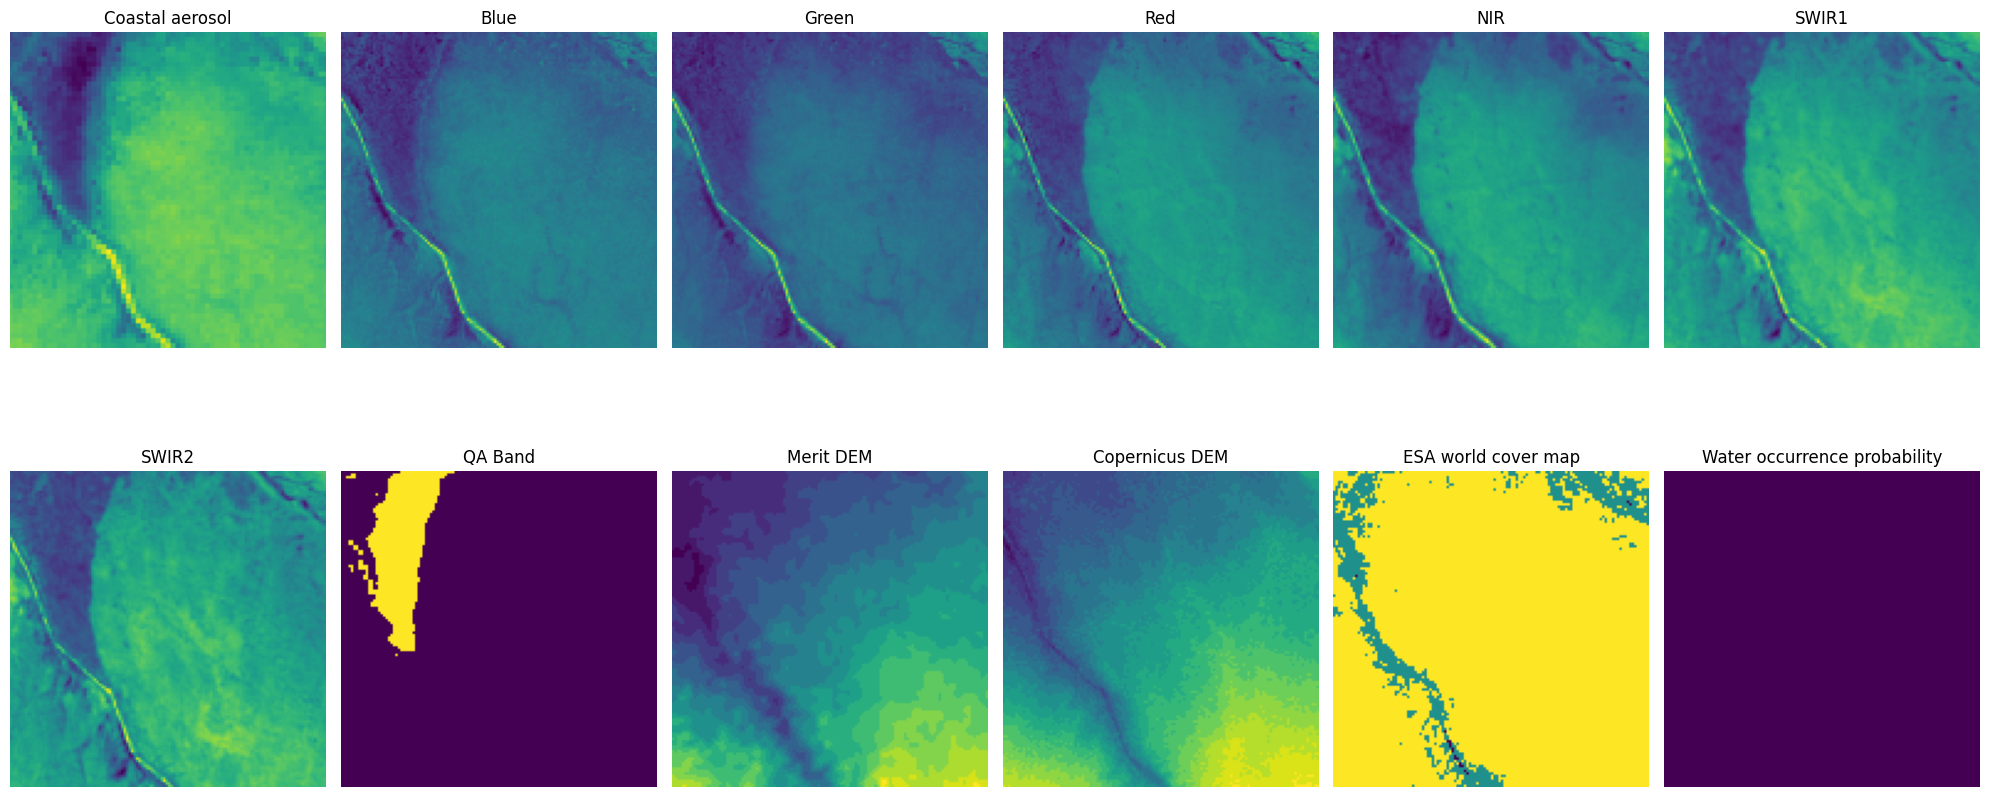

In [8]:
sample_image = os.path.join(IMAGES_DIR, "/kaggle/input/datasets/armia123/satellite-img/data/images/106.tif")

def visualize_bands(image_path):
    with rasterio.open(image_path) as src:
        img = src.read()

    band_names = [
        "Coastal aerosol", "Blue", "Green", "Red", "NIR", "SWIR1", 
        "SWIR2", "QA Band", "Merit DEM", "Copernicus DEM",
        "ESA world cover map", "Water occurrence probability"
    ]

    plt.figure(figsize=(20, 10))
    for i in range(12):
        plt.subplot(2, 6, i+1)
        plt.imshow(img[i], cmap='viridis')
        plt.title(band_names[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if os.path.exists(sample_image):
    visualize_bands(sample_image)


In [9]:
import os
from sklearn.model_selection import train_test_split

image_dir = "/kaggle/working/clean_dataset/images"
label_dir = "/kaggle/working/clean_dataset/labels"

images = sorted([f for f in os.listdir(image_dir) if f.endswith(".tif")])

train_imgs, temp_imgs = train_test_split(
    images, test_size=0.2, random_state=42
)

val_imgs, test_imgs = train_test_split(
    temp_imgs, test_size=0.5, random_state=42
)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 244
Val: 31
Test: 31


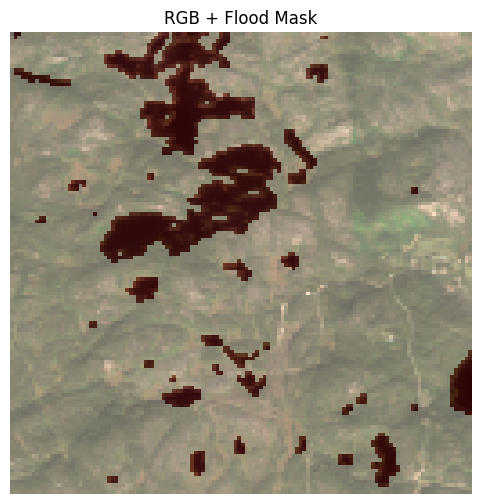

In [10]:
image_dir = "/kaggle/input/datasets/armia123/satellite-img/data/images"
mask_dir  = "/kaggle/input/datasets/armia123/satellite-img/data/labels"

img_name = sorted(os.listdir(image_dir))[0]

with rasterio.open(os.path.join(image_dir, img_name)) as src:
    img = src.read().transpose(1,2,0)

mask = cv2.imread(os.path.join(mask_dir, img_name.replace(".tif",".png")), 0)

rgb = np.stack([img[:,:,3], img[:,:,2], img[:,:,1]], axis=-1)
rgb = (rgb - rgb.min())/(rgb.max()-rgb.min()+1e-6)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.imshow(mask, cmap="Reds", alpha=0.4)
plt.title("RGB + Flood Mask")
plt.axis("off")
plt.show()

In [11]:
import numpy as np
import rasterio
import cv2
import os

def load_data(image_list, image_dir, label_dir):

    X = []
    Y = []

    for img_name in image_list:

        img_path = os.path.join(image_dir, img_name)
        with rasterio.open(img_path) as src:
            img = src.read().transpose(1,2,0).astype("float32")

        # Normalize per band
        for i in range(img.shape[2]):
            band = img[:,:,i]
            img[:,:,i] = (band - band.min()) / (band.max() - band.min() + 1e-6)

        mask_path = os.path.join(label_dir, img_name.replace(".tif", ".png"))
        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype("float32")

        X.append(img)
        Y.append(mask)

    X = np.array(X)
    Y = np.array(Y)

    Y = np.expand_dims(Y, axis=3)

    return X, Y

In [12]:
X_train, y_train = load_data(train_imgs, image_dir, label_dir)
X_val, y_val     = load_data(val_imgs, image_dir, label_dir)
X_test, y_test   = load_data(test_imgs, image_dir, label_dir)

print(X_train.shape, y_train.shape)

(244, 128, 128, 12) (244, 128, 128, 1)


In [13]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from keras import backend as K
import tensorflow as tf

def jacard_coef(y_true, y_pred):

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (intersection + 1.0) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) -
        intersection + 1.0
    )
def unet_water_model(IMG_HEIGHT=128, IMG_WIDTH=128, IMG_CHANNELS=12):
    strategy = tf.distribute.MirroredStrategy()
    
    with strategy.scope():
        inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
        s = inputs
    
        # Encoder
        c1 = Conv2D(16, (3,3), activation='relu', padding='same')(s)
        c1 = Dropout(0.2)(c1)
        c1 = Conv2D(16, (3,3), activation='relu', padding='same')(c1)
        p1 = MaxPooling2D((2,2))(c1)
    
        c2 = Conv2D(32, (3,3), activation='relu', padding='same')(p1)
        c2 = Dropout(0.2)(c2)
        c2 = Conv2D(32, (3,3), activation='relu', padding='same')(c2)
        p2 = MaxPooling2D((2,2))(c2)
    
        c3 = Conv2D(64, (3,3), activation='relu', padding='same')(p2)
        c3 = Dropout(0.2)(c3)
        c3 = Conv2D(64, (3,3), activation='relu', padding='same')(c3)
        p3 = MaxPooling2D((2,2))(c3)
    
        c4 = Conv2D(128, (3,3), activation='relu', padding='same')(p3)
        c4 = Dropout(0.2)(c4)
        c4 = Conv2D(128, (3,3), activation='relu', padding='same')(c4)
        p4 = MaxPooling2D((2,2))(c4)
    
        c5 = Conv2D(256, (3,3), activation='relu', padding='same')(p4)
        c5 = Dropout(0.3)(c5)
        c5 = Conv2D(256, (3,3), activation='relu', padding='same')(c5)
    
        # Decoder
        u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c5)
        u6 = concatenate([u6, c4])
        c6 = Conv2D(128, (3,3), activation='relu', padding='same')(u6)
        c6 = Dropout(0.2)(c6)
        c6 = Conv2D(128, (3,3), activation='relu', padding='same')(c6)
    
        u7 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c6)
        u7 = concatenate([u7, c3])
        c7 = Conv2D(64, (3,3), activation='relu', padding='same')(u7)
        c7 = Dropout(0.2)(c7)
        c7 = Conv2D(64, (3,3), activation='relu', padding='same')(c7)
    
        u8 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c7)
        u8 = concatenate([u8, c2])
        c8 = Conv2D(32, (3,3), activation='relu', padding='same')(u8)
        c8 = Dropout(0.2)(c8)
        c8 = Conv2D(32, (3,3), activation='relu', padding='same')(c8)
    
        u9 = Conv2DTranspose(16, (2,2), strides=(2,2), padding='same')(c8)
        u9 = concatenate([u9, c1])
        c9 = Conv2D(16, (3,3), activation='relu', padding='same')(u9)
        c9 = Dropout(0.2)(c9)
        c9 = Conv2D(16, (3,3), activation='relu', padding='same')(c9)
    
        outputs = Conv2D(1, (1,1), activation='sigmoid')(c9)
    
        model = Model(inputs=[inputs], outputs=[outputs])

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy', jacard_coef]
        )

        model.summary()
    return model

In [15]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_keras_model.h5",
    monitor="val_jacard_coef",   
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_jacard_coef",
    mode="max",
    patience=10,   
    verbose=1,
    restore_best_weights=True
)
model = unet_water_model()

history = model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stop]
)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1772580569.753878      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772580569.759914      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,744 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0]  

 Total params: 1,942,401 (7.41 MB)

...

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9831 - jacard_coef: 0.9079 - loss: 0.0405 - val_accuracy: 0.9787 - val_jacard_coef: 0.8953 - val_loss: 0.0704
Epoch 141/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9837 - jacard_coef: 0.8987 - loss: 0.0392
Epoch 141: val_jacard_coef did not improve from 0.89535
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9836 - jacard_coef: 0.8961 - loss: 0.0395 - val_accuracy: 0.9783 - val_jacard_coef: 0.8932 - val_loss: 0.0760
Epoch 142/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9839 - jacard_coef: 0.9091 - loss: 0.0391
Epoch 142: val_jacard_coef did not improve from 0.89535
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9838 - jacard_coef: 0.9080 - loss: 0.0395 - val_accuracy: 0.9775 - val_jacard_coef: 0.8865 - val_loss: 0.0720
Epoch 143/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9832 - jacard_coef: 0.9095 - loss: 0.0407
Epoch 143: val_jacard_coef did not improve from 0.89535
16/16 ━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9826 - jacard_coef: 0.8863 - loss: 0.0423 - val_accuracy: 0.9786 - val_jacard_coef: 0.8965 - val_loss: 0.0737
Epoch 149/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9851 - jacard_coef: 0.9101 - loss: 0.0361
Epoch 149: val_jacard_coef did not improve from 0.89655
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9850 - jacard_coef: 0.9095 - loss: 0.0363 - val_accuracy: 0.9777 - val_jacard_coef: 0.8915 - val_loss: 0.0767
Epoch 150/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9840 - jacard_coef: 0.9119 - loss: 0.0386
Epoch 150: val_jacard_coef did not improve from 0.89655
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9839 - jacard_coef: 0.9110 - loss: 0.0387 - val_accuracy: 0.9782 - val_jacard_coef: 0.8944 - val_loss: 0.0770
Epoch 151/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9828 - jacard_coef: 0.9164 - loss: 0.0411
Epoch 151: val_jacard_coef did not improve from 0.89655
16/16 ━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9847 - jacard_coef: 0.9151 - loss: 0.0363 - val_accuracy: 0.9789 - val_jacard_coef: 0.8976 - val_loss: 0.0750
Epoch 153/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9839 - jacard_coef: 0.9089 - loss: 0.0390
Epoch 153: val_jacard_coef did not improve from 0.89759
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9839 - jacard_coef: 0.9071 - loss: 0.0390 - val_accuracy: 0.9786 - val_jacard_coef: 0.8963 - val_loss: 0.0762
Epoch 154/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9852 - jacard_coef: 0.9136 - loss: 0.0355
Epoch 154: val_jacard_coef did not improve from 0.89759
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9851 - jacard_coef: 0.9121 - loss: 0.0358 - val_accuracy: 0.9785 - val_jacard_coef: 0.8968 - val_loss: 0.0742
Epoch 155/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9841 - jacard_coef: 0.9093 - loss: 0.0382
Epoch 155: val_jacard_coef did not improve from 0.89759
16/16 ━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9848 - jacard_coef: 0.9160 - loss: 0.0367 - val_accuracy: 0.9788 - val_jacard_coef: 0.8988 - val_loss: 0.0741
Epoch 157/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9842 - jacard_coef: 0.9153 - loss: 0.0376
Epoch 157: val_jacard_coef did not improve from 0.89878
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9843 - jacard_coef: 0.9149 - loss: 0.0376 - val_accuracy: 0.9785 - val_jacard_coef: 0.8953 - val_loss: 0.0729
Epoch 158/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9848 - jacard_coef: 0.9228 - loss: 0.0365
Epoch 158: val_jacard_coef improved from 0.89878 to 0.90172, saving model to best_keras_model.h5


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9848 - jacard_coef: 0.9216 - loss: 0.0366 - val_accuracy: 0.9799 - val_jacard_coef: 0.9017 - val_loss: 0.0725
Epoch 159/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9838 - jacard_coef: 0.9132 - loss: 0.0388
Epoch 159: val_jacard_coef did not improve from 0.90172
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9839 - jacard_coef: 0.9134 - loss: 0.0386 - val_accuracy: 0.9785 - val_jacard_coef: 0.8981 - val_loss: 0.0737
Epoch 160/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9859 - jacard_coef: 0.9116 - loss: 0.0340
Epoch 160: val_jacard_coef did not improve from 0.90172
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9858 - jacard_coef: 0.9113 - loss: 0.0343 - val_accuracy: 0.9791 - val_jacard_coef: 0.8996 - val_loss: 0.0706
Epoch 161/200
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9850 - jacard_coef: 0.9175 - loss: 0.0360
Epoch 161: val_jacard_coef did not improve from 0.90172
16/16 ━━━━

In [21]:
y_pred = model.predict(X_test)

I0000 00:00:1772588647.977045     141 service.cc:152] XLA service 0x7e2440211620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772588647.977078     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772588647.977082     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772588648.174619     141 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


I0000 00:00:1772588651.345433     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [22]:
import numpy as np

y_pred_bin = (y_pred > 0.5).astype(np.float32)

In [23]:
eps = 1e-6

TP = np.sum(y_pred_bin * y_test)
FP = np.sum(y_pred_bin * (1 - y_test))
FN = np.sum((1 - y_pred_bin) * y_test)

precision = TP / (TP + FP + eps)
recall    = TP / (TP + FN + eps)
f1        = 2 * precision * recall / (precision + recall + eps)
iou       = TP / (TP + FP + FN + eps)

print("Test IoU:", iou)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1:", f1)

Test IoU: 0.81286764
Test Precision: 0.93898374
Test Recall: 0.85819864
Test F1: 0.89677507


In [16]:
import numpy as np

images_with_flood = 0
images_without_flood = 0

for i in range(len(y_test)):
    if np.sum(y_test[i]) > 0:
        images_with_flood += 1
    else:
        images_without_flood += 1

print("Images WITH flood:", images_with_flood)
print("Images WITHOUT flood:", images_without_flood)

Images WITH flood: 22
Images WITHOUT flood: 9


In [24]:
pred_with_flood = 0
pred_without_flood = 0

for i in range(len(y_pred_bin)):
    if np.sum(y_pred_bin[i]) > 0:
        pred_with_flood += 1
    else:
        pred_without_flood += 1

print("Predicted flood in images:", pred_with_flood)
print("Predicted no flood in images:", pred_without_flood)

Predicted flood in images: 23
Predicted no flood in images: 8


In [25]:
correct = 0

for i in range(len(y_test)):
    
    gt_has_flood = np.sum(y_test[i]) > 0
    pred_has_flood = np.sum(y_pred_bin[i]) > 0
    
    if gt_has_flood == pred_has_flood:
        correct += 1

image_level_accuracy = correct / len(y_test)

print("Image-level Accuracy:", image_level_accuracy)

Image-level Accuracy: 0.9032258064516129


In [27]:
print(X_test.shape)

(31, 128, 128, 12)


TP: 21
FN: 1
FP: 2
TN: 7

Showing 3 examples for: True Positive (Flood detected correctly)


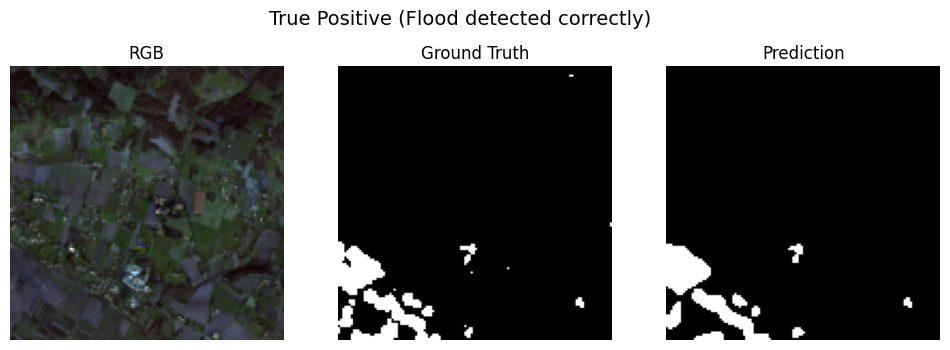

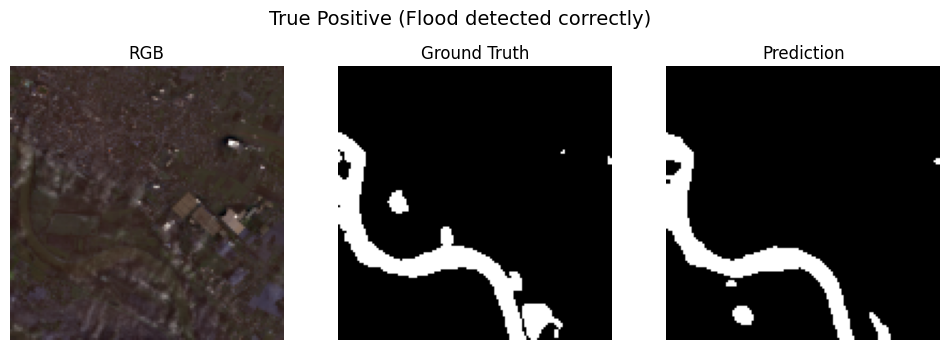

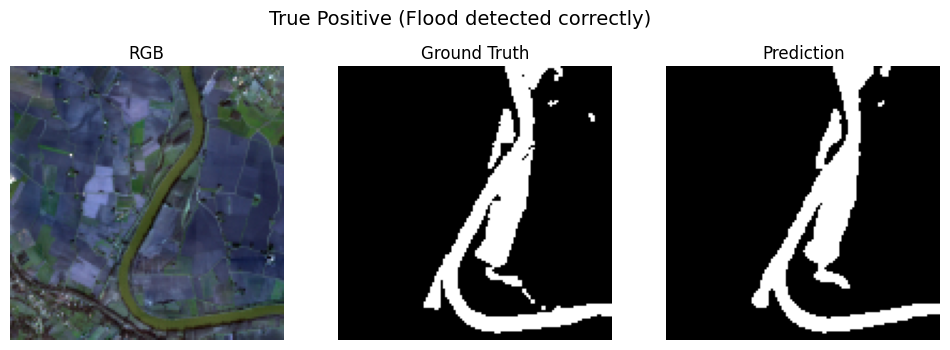


Showing 1 examples for: False Negative (Missed flood)


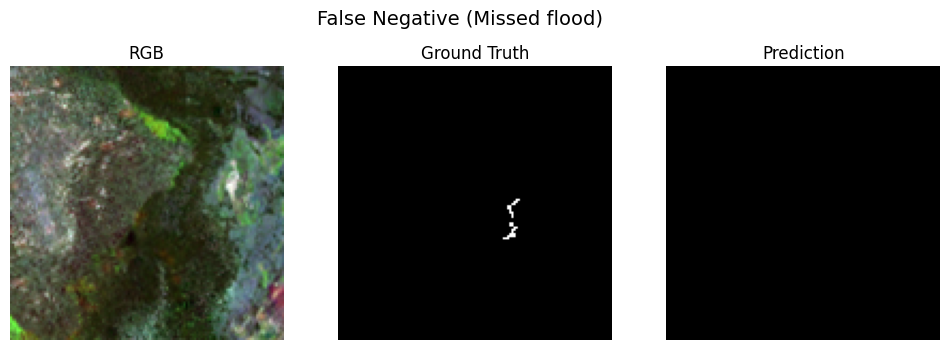


Showing 2 examples for: False Positive (False alarm)


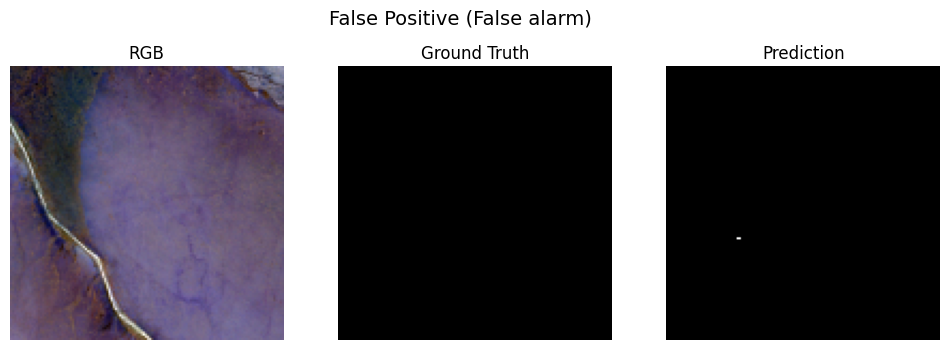

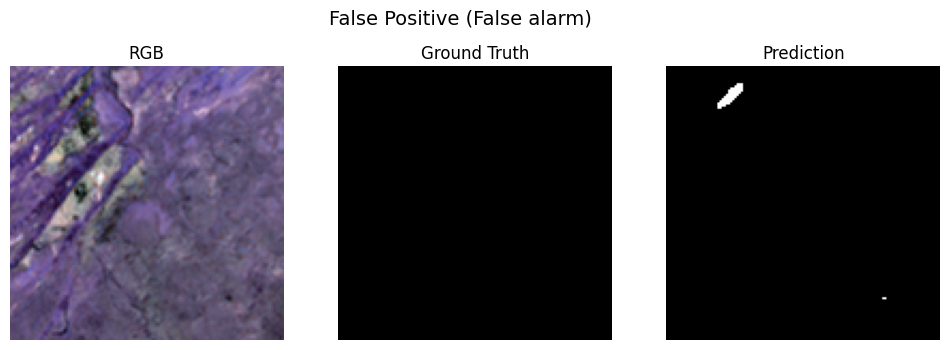


Showing 3 examples for: True Negative (Correct no flood)


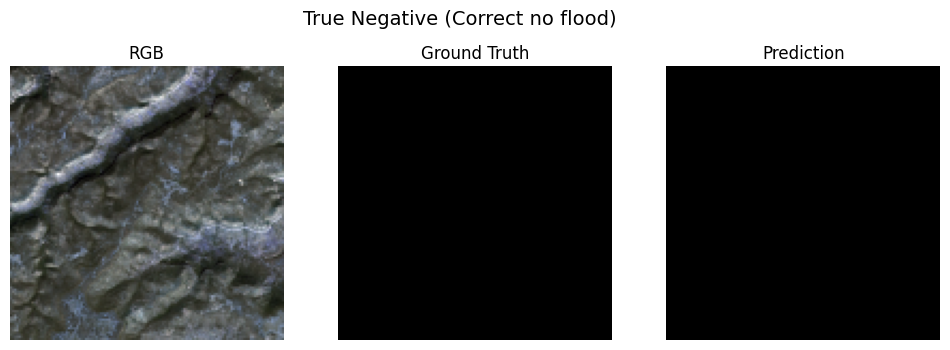

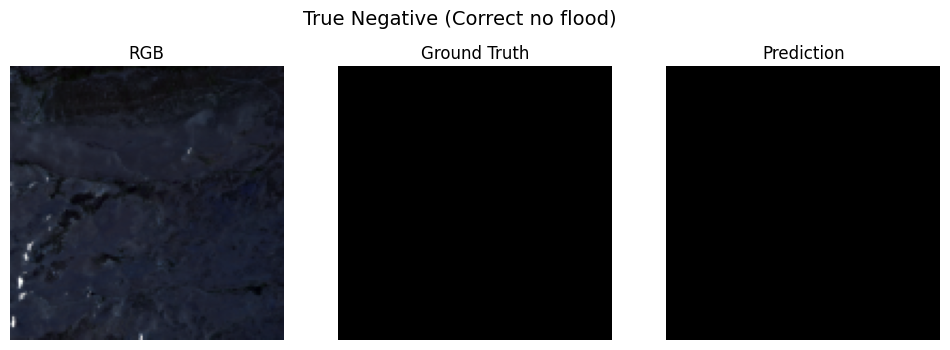

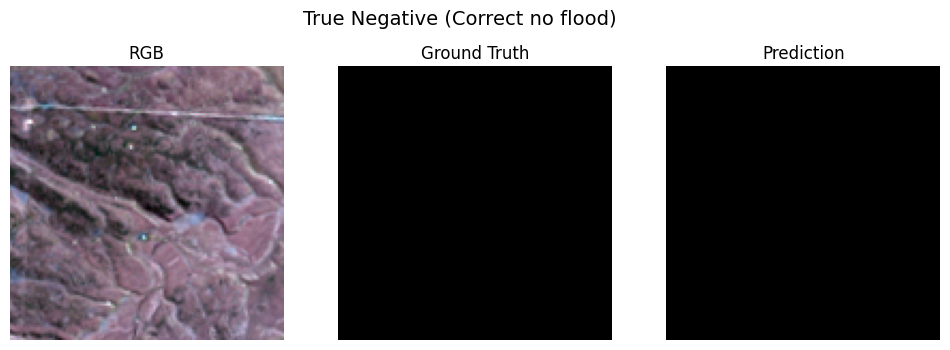

In [28]:
import matplotlib.pyplot as plt
import numpy as np


def show_examples(indices, title, max_images=3):

    if len(indices) == 0:
        print(f"No examples found for {title}")
        return

    print(f"\nShowing {min(len(indices), max_images)} examples for: {title}")

    for idx in indices[:max_images]:

        img  = X_test[idx]                 
        mask = y_test[idx][:,:,0]
        pred = y_pred_bin[idx][:,:,0]

        rgb = img[:,:,1:4]

        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

        plt.figure(figsize=(12,4))
        plt.suptitle(title, fontsize=14)

        plt.subplot(1,3,1)
        plt.title("RGB")
        plt.imshow(rgb)
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred, cmap="gray")
        plt.axis("off")

        plt.show()




TP_idx = []
FP_idx = []
FN_idx = []
TN_idx = []

for i in range(len(y_test)):

    gt_has = np.sum(y_test[i]) > 0
    pred_has = np.sum(y_pred_bin[i]) > 0

    if gt_has and pred_has:
        TP_idx.append(i)
    elif gt_has and not pred_has:
        FN_idx.append(i)
    elif not gt_has and pred_has:
        FP_idx.append(i)
    else:
        TN_idx.append(i)


print("TP:", len(TP_idx))
print("FN:", len(FN_idx))
print("FP:", len(FP_idx))
print("TN:", len(TN_idx))




show_examples(TP_idx, "True Positive (Flood detected correctly)")
show_examples(FN_idx, "False Negative (Missed flood)")
show_examples(FP_idx, "False Positive (False alarm)")
show_examples(TN_idx, "True Negative (Correct no flood)")

In [47]:
!pip install -q albumentations

In [57]:
import os
import numpy as np
import torch
import torch.nn as nn
import rasterio
import cv2
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A

from torch.utils.data import Dataset, DataLoader

In [58]:
def compute_mean_std(image_list, image_dir):

    channel_sum = 0
    channel_sq_sum = 0
    num_pixels = 0

    for img_name in image_list:
        img_path = os.path.join(image_dir, img_name)

        with rasterio.open(img_path) as src:
            img = src.read().astype("float32")

        img = np.transpose(img, (1,2,0))

        channel_sum += img.sum(axis=(0,1))
        channel_sq_sum += (img ** 2).sum(axis=(0,1))
        num_pixels += img.shape[0] * img.shape[1]

    mean = channel_sum / num_pixels
    std = np.sqrt(channel_sq_sum / num_pixels - mean**2)

    return mean, std


mean, std = compute_mean_std(train_imgs, image_dir)
print("Mean:", mean)
print("Std:", std)

Mean: [ 402.96365   502.33768   835.3375    987.08167  2104.5688   1974.9495
 1360.7394    103.46341   127.68327   276.31073    35.57093    10.141439]
Std: [ 266.38226   324.18063   419.3235    591.7993   1075.8915   1213.1802
  978.0237     49.047916 1312.2366    471.6782     20.373262   28.250145]


In [59]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

In [60]:
class FloodDataset(Dataset):

    def __init__(self, image_list, image_dir, label_dir,
                 mean, std, transform=None):

        self.image_list = image_list
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.mean = mean
        self.std = std
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):

        img_name = self.image_list[idx]
        img_path = os.path.join(self.image_dir, img_name)

        with rasterio.open(img_path) as src:
            img = src.read().astype("float32")

        img = np.transpose(img, (1,2,0))

        mask_path = os.path.join(
            self.label_dir,
            img_name.replace(".tif",".png")
        )

        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype("float32")

        # ===== Augmentation =====
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        # ===== Normalization =====
        img = (img - self.mean) / (self.std + 1e-6)

        img = torch.tensor(img.transpose(2,0,1), dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask

In [61]:
train_dataset = FloodDataset(
    train_imgs,
    image_dir,
    label_dir,
    mean,
    std,
    transform=train_transform
)

val_dataset = FloodDataset(
    val_imgs,
    image_dir,
    label_dir,
    mean,
    std,
    transform=val_transform
)

test_dataset = FloodDataset(
    test_imgs,
    image_dir,
    label_dir,
    mean,
    std,
    transform=None
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [62]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=12,
    classes=1,
    activation=None
)

model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [66]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    inter = (pred * target).sum(dim=(1,2,3))
    dice = (2*inter + smooth) / (
        pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + smooth
    )
    return 1 - dice.mean()

def compute_iou(preds, targets, thr=0.5, eps=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > thr).float()

    inter = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) - inter

    return ((inter + eps) / (union + eps)).mean()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
)

In [71]:
def evaluate(loader):
    model.eval()
    total_loss = 0
    total_iou = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            loss = bce(preds, masks) + dice_loss(preds, masks)

            total_loss += loss.item()
            total_iou += compute_iou(preds, masks).item()

    return total_loss/len(loader), total_iou/len(loader)


best_iou = 0
epochs = 100

for epoch in range(epochs):

    model.train()
    train_loss = 0
    train_iou = 0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = bce(preds, masks) + dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou += compute_iou(preds, masks).item()

    scheduler.step(val_iou)

    train_loss /= len(train_loader)
    train_iou  /= len(train_loader)

    val_loss, val_iou = evaluate(val_loader)

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_model.pth")
        print(" Saved best model")

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   IoU: {val_iou:.4f}")
    print("--------------------------------------------------")

 Saved best model
Epoch 1
Train Loss: 0.3296 | Train IoU: 0.7364
Val   Loss: 0.2599 | Val   IoU: 0.8256
--------------------------------------------------
 Saved best model
Epoch 2
Train Loss: 0.3205 | Train IoU: 0.7415
Val   Loss: 0.2384 | Val   IoU: 0.8304
--------------------------------------------------
 Saved best model
Epoch 3
Train Loss: 0.3110 | Train IoU: 0.7419
Val   Loss: 0.2338 | Val   IoU: 0.8324
--------------------------------------------------
Epoch 4
Train Loss: 0.3318 | Train IoU: 0.7348
Val   Loss: 0.2410 | Val   IoU: 0.8310
--------------------------------------------------
Epoch 5
Train Loss: 0.3259 | Train IoU: 0.7436
Val   Loss: 0.2469 | Val   IoU: 0.8249
--------------------------------------------------
 Saved best model
Epoch 6
Train Loss: 0.3048 | Train IoU: 0.7441
Val   Loss: 0.2299 | Val   IoU: 0.8340
--------------------------------------------------
 Saved best model
Epoch 7
Train Loss: 0.3307 | Train IoU: 0.7366
Val   Loss: 0.2314 | Val   IoU: 0.8347
--

In [74]:
model.eval()

f1_total = 0
num_batches = 0

with torch.no_grad():
    for imgs, masks in test_loader:

        imgs  = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float()

        # Flatten
        preds = preds.view(-1)
        masks = masks.view(-1)

        TP = (preds * masks).sum()
        FP = (preds * (1 - masks)).sum()
        FN = ((1 - preds) * masks).sum()

        f1 = (2 * TP + 1e-6) / (2 * TP + FP + FN + 1e-6)

        f1_total += f1.item()
        num_batches += 1

f1_score = f1_total / num_batches

print(f"Test F1 Score: {f1_score:.4f}")

Test F1 Score: 0.8798


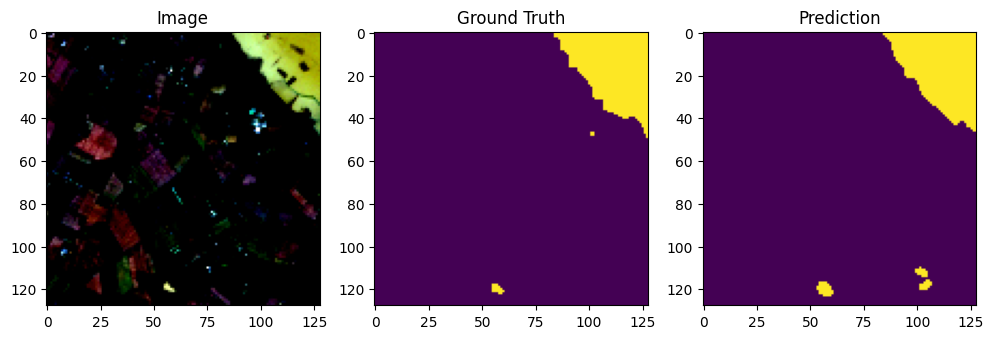

In [75]:
model.eval()

imgs, masks = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    preds = model(imgs)

pred = (torch.sigmoid(preds[0])>0.5).cpu().numpy()[0]
mask = masks[0].numpy()[0]

rgb = imgs[0].cpu().numpy()
rgb = np.stack([rgb[3], rgb[2], rgb[1]], axis=-1)

plt.figure(figsize=(12,5))

plt.subplot(131)
plt.title("Image")
plt.imshow(rgb)

plt.subplot(132)
plt.title("Ground Truth")
plt.imshow(mask)

plt.subplot(133)
plt.title("Prediction")
plt.imshow(pred)

plt.show()